# Companion notebook — Defect Classification, Lecture 2
### *Wafer Maps: The Obvious Approach and What It Hides*

**Course:** AI for Semiconductor Manufacturing (ECE 8803-AI4) · Asif Khan, Georgia Tech
**Course website:** https://aikhan123.github.io/khan-lab-website/ai-semiconductors-course.html

This notebook reproduces, from scratch, every figure in Lecture 2, in the order the
slides present them. Each figure is preceded by a note giving the **slide it appears on**
and what it shows. Everything here runs on a CPU in a few minutes; the convolutional
network at the end is given as complete PyTorch code plus the numbers reported in the
lecture, since training it well wants a GPU.

**Data:** the WM-811K development subset, `wm811k_dev.npz` (~26,000 wafer maps), the same
file that ships with the hands-on exercise. Set `DATA` below to its location.

> Wafer-map data set: M.-J. Wu, J.-S. R. Jang, J.-L. Chen, *Wafer Map Failure Pattern
> Recognition and Similarity Ranking for Large-Scale Data Sets*, IEEE Trans. Semiconductor
> Manufacturing, 28(1), 1–12, 2015. doi:10.1109/TSM.2014.2364237

## 0 · Setup

Imports, the Georgia Tech colour palette used throughout the slides, the wafer-map
colour map (each pixel is `0` outside the wafer, `1` a die that passed, `2` a die that
failed), and a loader for the dev set.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch, Patch

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})

# Georgia Tech palette (matches the slides)
NAVY="#003057"; GOLD="#B3A369"; BUZZ="#EAAA00"; FAIL="#E8503A"; PASS="#4A7FB5"
GOOD="#1A7A3A"; BAD="#B00020"; MUT="#6B7280"; BODY="#2A2E33"; GRID="#DDE2E7"

# wafer colour map: 0 = outside wafer, 1 = pass, 2 = fail
WAFER_CMAP = ListedColormap(["#1a1a1a", PASS, FAIL])

def show(fig=None):
    plt.tight_layout(); plt.show()

In [2]:
# ---- load the development subset -------------------------------------------
# Point DATA at wm811k_dev.npz (ships with the exercise).
DATA = "wm811k_dev.npz"   # e.g. "WM-811k/wm811k_dev.npz"

d = np.load(DATA, allow_pickle=True)
X    = d["X"]            # (N, 64, 64) uint8 in {0,1,2}
y    = d["y"].astype(str)  # (N,) class names
lot  = d["lot"].astype(str)  # (N,) lot id — used for grouped splitting

CLASSES = ["none","Edge-Ring","Edge-Loc","Center","Loc","Scratch","Random","Donut","Near-full"]
print(f"{len(X):,} wafers · {X.shape[1]}x{X.shape[2]} maps · {len(set(y))} classes · {len(set(lot)):,} lots")

25,956 wafers · 64x64 maps · 9 classes · 1,618 lots


## 1 · What the data is  (Part 1 · Section 1–2)

### Figure — a single wafer map
*Slide: "What a wafer map actually is."* A wafer map is not a photograph: every pixel is
one die, and its value is a categorical pass/fail flag, not a brightness.

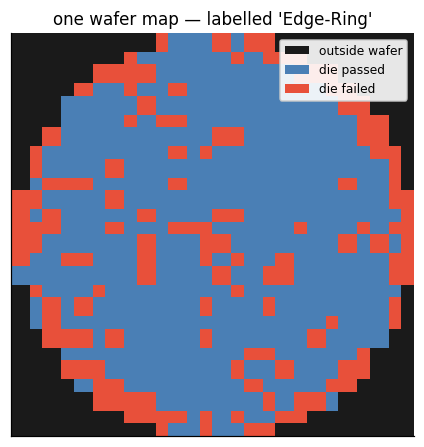

In [3]:
def show_wafer(ax, w, title=""):
    ax.imshow(w, cmap=WAFER_CMAP, vmin=0, vmax=2, interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=11)

# pick a clear Edge-Ring example
i = np.where(y == "Edge-Ring")[0][0]
fig, ax = plt.subplots(figsize=(4.2,4.2))
show_wafer(ax, X[i], f"one wafer map — labelled '{y[i]}'")
legend = [Patch(facecolor="#1a1a1a", label="outside wafer"),
          Patch(facecolor=PASS, label="die passed"),
          Patch(facecolor=FAIL, label="die failed")]
ax.legend(handles=legend, loc="upper right", fontsize=8, framealpha=0.9)
show()

### Figure — the nine failure classes
*Slide: "Nine failure classes."* One example of each labelled pattern. These spatial
signatures — a ring at the edge, a blob in the centre, a thin scratch — are what every
model in this lecture is trying to tell apart.

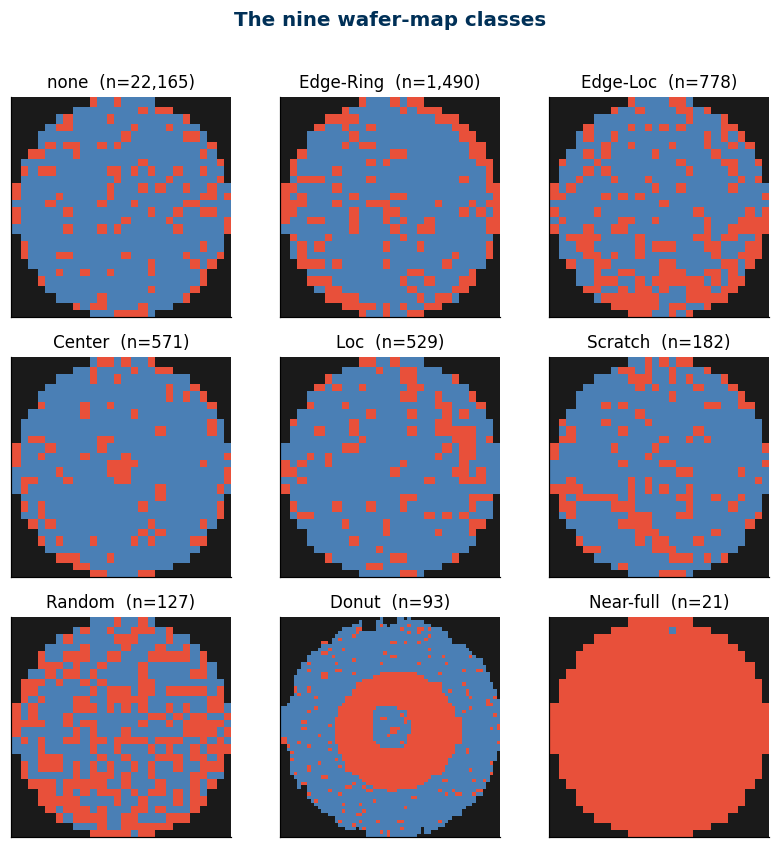

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(7.5, 7.6))
for ax, c in zip(axes.ravel(), CLASSES):
    idx = np.where(y == c)[0]
    show_wafer(ax, X[idx[0]], f"{c}  (n={len(idx):,})")
plt.suptitle("The nine wafer-map classes", y=1.01, fontsize=13, fontweight="bold", color=NAVY)
show()

### Figure — severe, structural class imbalance
*Slide: "Severe, structural class imbalance."* Almost everything is `none`. The rare
defect classes — the ones we most want to catch — are a tiny fraction of the data, which
is why plain accuracy will mislead us later.

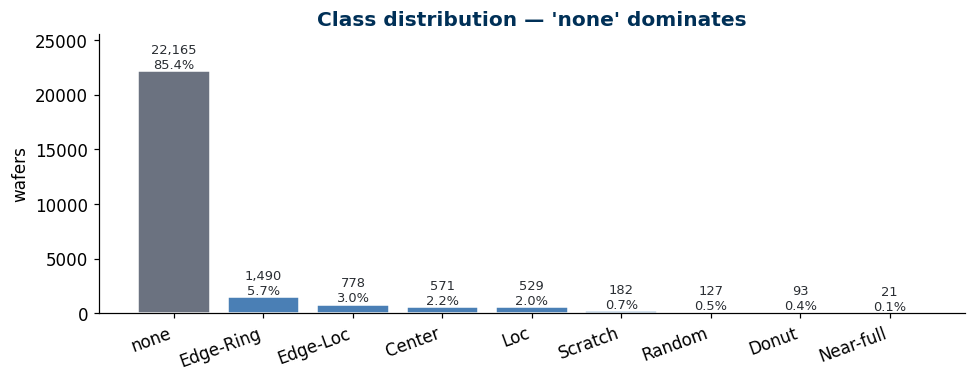

In [5]:
counts = {c: int((y == c).sum()) for c in CLASSES}
fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.bar(range(len(CLASSES)), [counts[c] for c in CLASSES],
              color=[MUT if c=="none" else PASS for c in CLASSES], edgecolor="white")
for b, c in zip(bars, CLASSES):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{counts[c]:,}\n{counts[c]/len(y)*100:.1f}%",
            ha="center", va="bottom", fontsize=8.5, color=BODY)
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=20, ha="right")
ax.set_ylabel("wafers"); ax.set_title("Class distribution — 'none' dominates", color=NAVY, fontweight="bold")
ax.set_ylim(0, max(counts.values())*1.15)
show()

### Figure — how much to trust a number (confidence interval)
*Slide: "Confidence intervals: how much to trust a number."* A test accuracy is an
estimate from a finite test set. The 95% Wald interval for a proportion,
$\hat p \pm 1.96\sqrt{\hat p(1-\hat p)/n}$, shows the interval shrinking as the test set
grows — the reason we spend wafers on the test split.

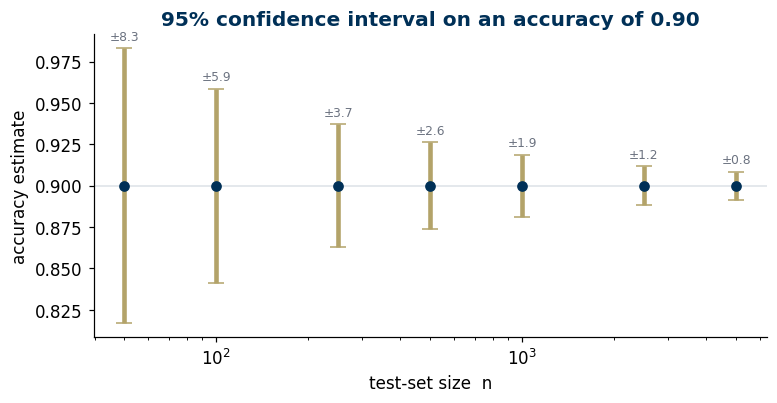

In [6]:
p = 0.90
ns = np.array([50, 100, 250, 500, 1000, 2500, 5000])
half = 1.96*np.sqrt(p*(1-p)/ns)
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.errorbar(ns, [p]*len(ns), yerr=half, fmt="o", color=NAVY, ecolor=GOLD, elinewidth=3, capsize=5)
for n,h in zip(ns, half):
    ax.text(n, p+h+0.005, f"±{h*100:.1f}", ha="center", fontsize=8, color=MUT)
ax.set_xscale("log"); ax.set_xlabel("test-set size  n"); ax.set_ylabel("accuracy estimate")
ax.set_title("95% confidence interval on an accuracy of 0.90", color=NAVY, fontweight="bold")
ax.axhline(p, color=GRID, lw=1)
show()

## 2 · Logistic regression from first principles  (Part 1 · Section 3)

To see the machinery clearly we use a two-feature toy problem — two Gaussian blobs — so
the model and its boundary can be drawn. Everything here is implemented by hand, exactly
as the slides derive it.

### Figure — two features, and the straight-line boundary
*Slide "Logistic regression: the model" (1/11).* Each point is one example with two
features $(x_1,x_2)$; colour is the label $y\in\{0,1\}$. Logistic regression can only
place a **straight** boundary.

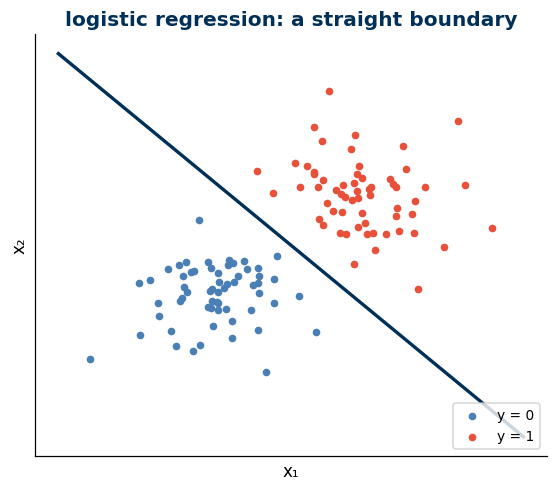

In [7]:
from sklearn.linear_model import LogisticRegression

g = np.random.default_rng(1)
n = 60
X0 = g.normal([-1.2,-1.0], 0.75, (n,2))
X1 = g.normal([ 1.3, 1.1], 0.75, (n,2))
Xt = np.vstack([X0, X1]); yt = np.r_[np.zeros(n), np.ones(n)]

def plot_toy(ax, w=None, b=None, title=""):
    ax.scatter(*Xt[yt==0].T, s=16, c=PASS, label="y = 0")
    ax.scatter(*Xt[yt==1].T, s=16, c=FAIL, label="y = 1")
    if w is not None:
        xs = np.array([Xt[:,0].min()-.5, Xt[:,0].max()+.5])
        ax.plot(xs, -(w[0]*xs+b)/w[1], color=NAVY, lw=2.2)
    ax.set_xlabel("x₁"); ax.set_ylabel("x₂"); ax.set_title(title, color=NAVY, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])

clf = LogisticRegression().fit(Xt, yt)
fig, ax = plt.subplots(figsize=(5.2,4.6))
plot_toy(ax, clf.coef_[0], clf.intercept_[0], "logistic regression: a straight boundary")
ax.legend(loc="lower right", fontsize=9); show()

### Figure — the nonlinearity: the sigmoid
*Slide "The nonlinearity: the sigmoid" (3/11).* The linear score $z=w_1x_1+w_2x_2+c$ is
squashed to a probability $h=g(z)=1/(1+e^{-z})$.

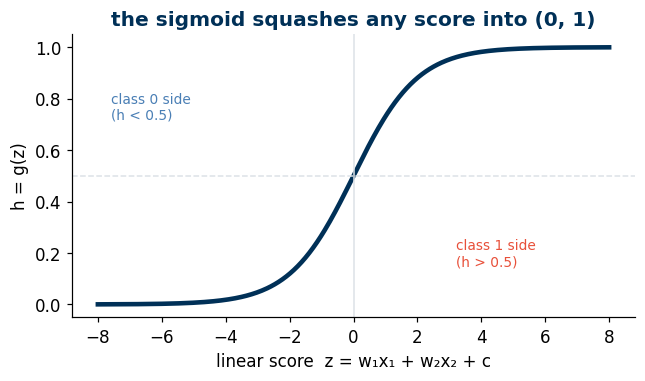

In [8]:
def sigmoid(z): return 1/(1+np.exp(-z))
z = np.linspace(-8,8,400)
fig, ax = plt.subplots(figsize=(6,3.6))
ax.plot(z, sigmoid(z), color=NAVY, lw=3)
ax.axhline(0.5, color=GRID, lw=1, ls="--"); ax.axvline(0, color=GRID, lw=1)
ax.set_xlabel("linear score  z = w₁x₁ + w₂x₂ + c"); ax.set_ylabel("h = g(z)")
ax.set_title("the sigmoid squashes any score into (0, 1)", color=NAVY, fontweight="bold")
ax.text(3.2, 0.15, "class 1 side\n(h > 0.5)", color=FAIL, fontsize=9)
ax.text(-7.6, 0.72, "class 0 side\n(h < 0.5)", color=PASS, fontsize=9)
show()

### Figure — logistic regression drawn as a single neuron
*Slide "The same model, drawn as a network" (2/11).* Two inputs feed one output node
through weights $w_1,w_2$. The **offset $c$** (the bias) is added **at the output node**,
riding in on a constant-1 unit — tied to no input.

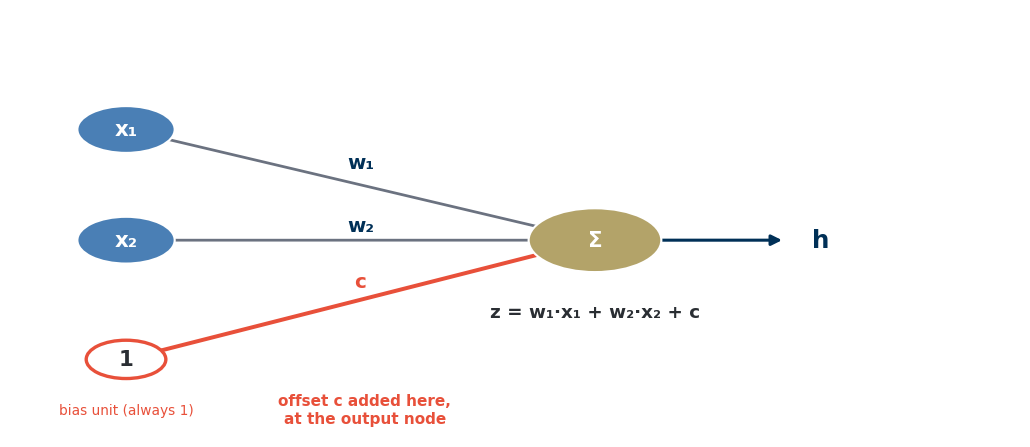

In [9]:
fig, ax = plt.subplots(figsize=(9.5,4.2)); ax.axis("off"); ax.set_xlim(0,1.14); ax.set_ylim(0,1)
x1=(0.13,0.72); x2=(0.13,0.46); bias=(0.13,0.18); out=(0.66,0.46)
def edge(p,q,color,lw,label,dy=0.03,lcol=None):
    ax.add_patch(FancyArrowPatch(p,q,arrowstyle="-|>",mutation_scale=13,color=color,lw=lw,shrinkA=13,shrinkB=19,zorder=2))
    ax.text((p[0]+q[0])/2, (p[1]+q[1])/2+dy, label, color=lcol or color, fontsize=13, fontweight="bold", ha="center")
edge(x1,out,MUT,1.8,"w₁",0.04,NAVY); edge(x2,out,MUT,1.8,"w₂",0.02,NAVY); edge(bias,out,FAIL,2.6,"c",0.03,FAIL)
for p,lab,col,tc,r in [(x1,"x₁",PASS,"white",0.055),(x2,"x₂",PASS,"white",0.055),
                       (bias,"1","white",BODY,0.045),(out,"Σ",GOLD,"white",0.075)]:
    ax.add_patch(Circle(p,r,facecolor=col,edgecolor=(FAIL if lab=="1" else "white"),lw=(2.2 if lab=="1" else 1.4),zorder=3))
    ax.text(*p,lab,color=tc,fontsize=14,fontweight="bold",ha="center",va="center",zorder=4)
ax.add_patch(FancyArrowPatch(out,(0.88,0.46),arrowstyle="-|>",mutation_scale=14,color=NAVY,lw=2,shrinkA=19,shrinkB=5))
ax.text(0.915,0.46,"h",color=NAVY,fontsize=16,fontweight="bold",ha="center",va="center")
ax.text(0.66,0.28,"z = w₁·x₁ + w₂·x₂ + c", ha="center", fontsize=12, color=BODY, fontweight="bold")
ax.text(0.13,0.05,"bias unit (always 1)", ha="center", color=FAIL, fontsize=9)
ax.text(0.40,0.10,"offset c added here,\nat the output node", ha="center", va="top", color=FAIL, fontsize=10, fontweight="bold")
show()

### The cost, and training by hand
*Slides "How wrong are we? The cost function" (4/11) and "The update rule for a, b, c"
(8/11).* The loss is the **cross-entropy**
$J=-\sum_i\big[y_i\log h_i+(1-y_i)\log(1-h_i)\big]$, and each weight is nudged downhill by
$\;w_j \leftarrow w_j-\alpha\cdot\frac1m\sum_i (h_i-y_i)\,x_{ij}$. We implement exactly that
and keep the whole trajectory so we can watch the line move.

In [10]:
def train_logreg(X, y, lr=0.3, iters=600):
    Xb = np.c_[X, np.ones(len(X))]           # append constant-1 column for the offset c
    w  = np.zeros(Xb.shape[1])
    hist_w, hist_J = [], []
    for t in range(iters):
        h = sigmoid(Xb @ w)
        J = -np.mean(y*np.log(h+1e-12) + (1-y)*np.log(1-h+1e-12))
        grad = Xb.T @ (h - y) / len(y)        # (prediction - truth) · input, averaged
        w -= lr * grad
        hist_w.append(w.copy()); hist_J.append(J)
    return np.array(hist_w), np.array(hist_J)

# start from a deliberately bad orientation so the rotation is visible
W, Jh = train_logreg(Xt, yt, lr=0.5, iters=600)
print(f"final loss J = {Jh[-1]:.3f}   accuracy = {np.mean((sigmoid(np.c_[Xt,np.ones(len(Xt))]@W[-1])>0.5)==yt):.2f}")

final loss J = 0.006   accuracy = 1.00


### Figure — the cross-entropy penalty per point
*Slide "How wrong are we? The cost function".* Each point's penalty is $-\log$ of the
probability the model gives its **true** class: near zero when confident and right, large
when confident and wrong.

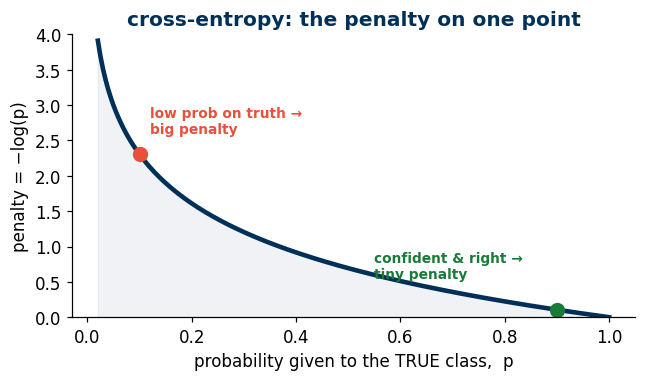

In [11]:
pp = np.linspace(0.02,1,200)
fig, ax = plt.subplots(figsize=(6,3.6))
ax.plot(pp, -np.log(pp), color=NAVY, lw=3); ax.fill_between(pp, -np.log(pp), color=NAVY, alpha=0.06)
ax.plot(0.9,-np.log(0.9),"o",color=GOOD,ms=9); ax.plot(0.1,-np.log(0.1),"o",color=FAIL,ms=9)
ax.text(0.55,0.55,"confident & right →\ntiny penalty",color=GOOD,fontsize=9,fontweight="bold")
ax.text(0.12,2.6,"low prob on truth →\nbig penalty",color=FAIL,fontsize=9,fontweight="bold")
ax.set_xlabel("probability given to the TRUE class,  p"); ax.set_ylabel("penalty = −log(p)")
ax.set_title("cross-entropy: the penalty on one point", color=NAVY, fontweight="bold"); ax.set_ylim(0,4)
show()

### Figure — the line evolves with the iterations
*Slide "The line evolves with the iterations" (9/11).* Snapshots of the same run: the
boundary rotates into the gap between the clusters as $J$ falls.

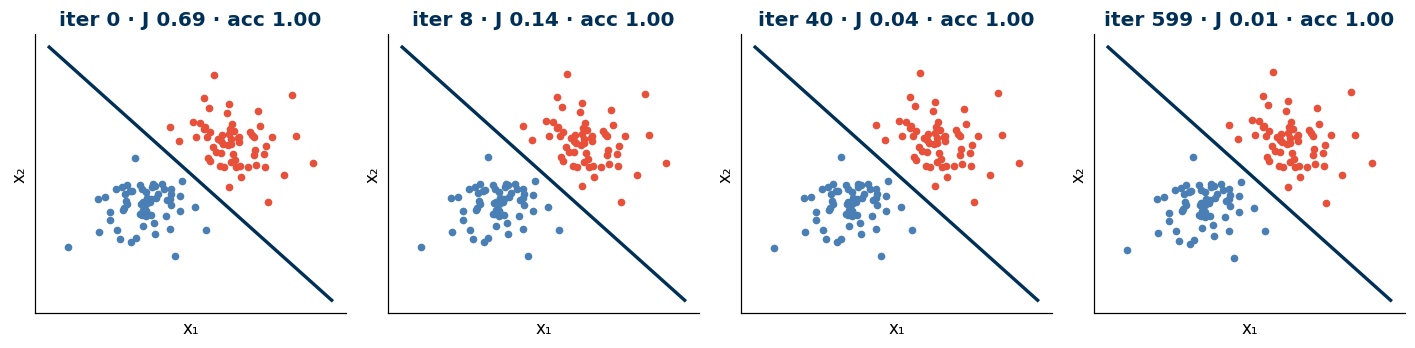

In [12]:
snaps = [0, 8, 40, 599]
fig, axes = plt.subplots(1,4, figsize=(13,3.3))
for ax,t in zip(axes, snaps):
    w = W[t]
    acc = np.mean((sigmoid(np.c_[Xt,np.ones(len(Xt))]@w)>0.5)==yt)
    plot_toy(ax, w[:2], w[2], f"iter {t} · J {Jh[t]:.2f} · acc {acc:.2f}")
show()

### Figure — J falls until it converges
*Slide "J falls until it converges" (10/11).* The loss-versus-iteration curve: steep at
first, then flat. That flattening is convergence.

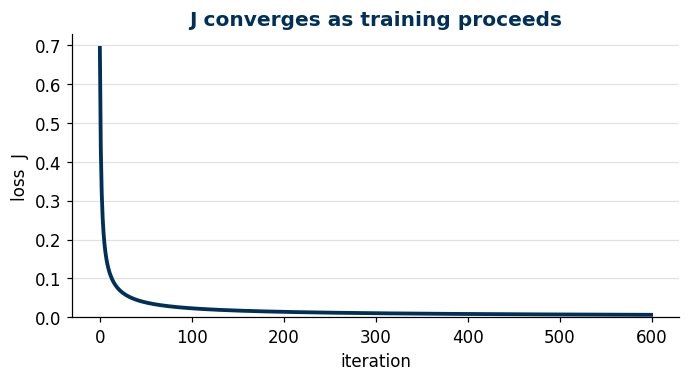

In [13]:
fig, ax = plt.subplots(figsize=(6.4,3.6))
ax.plot(Jh, color=NAVY, lw=2.5)
ax.set_xlabel("iteration"); ax.set_ylabel("loss  J"); ax.set_ylim(0, Jh.max()*1.05)
ax.set_title("J converges as training proceeds", color=NAVY, fontweight="bold"); ax.grid(axis="y", color=GRID)
show()

### Figure — precision, recall, F1
*Slide "Precision, recall, F1, and macro-F1."* From the four counts of a confusion matrix:
precision $=TP/(TP+FP)$ counts down the predicted column, recall $=TP/(TP+FN)$ across the
true row, and $F1=2PR/(P+R)$ is their harmonic mean.

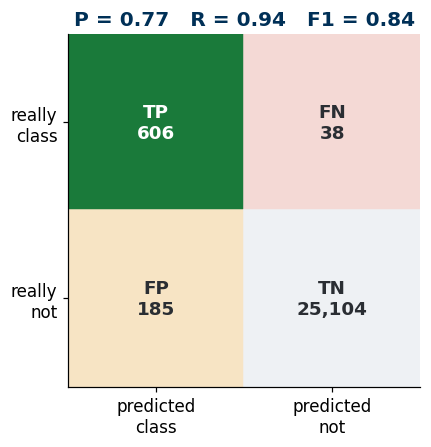

In [14]:
TP,FN,FP,TN = 606, 38, 185, 25104
cm = np.array([[TP,FN],[FP,TN]])
fig, ax = plt.subplots(figsize=(5.2,4.2))
ax.imshow([[0,0],[0,0]], cmap="Greys", vmin=0, vmax=1)
labels = [["TP\n"+f"{TP}", "FN\n"+f"{FN}"],["FP\n"+f"{FP}", "TN\n"+f"{TN:,}"]]
cols = [[GOOD, "#F4D9D5"],["#F7E4C4", "#EEF1F4"]]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1, color=cols[i][j]))
        ax.text(j,i,labels[i][j], ha="center", va="center", fontsize=12,
                color="white" if (i,j)==(0,0) else BODY, fontweight="bold")
ax.set_xticks([0,1]); ax.set_xticklabels(["predicted\nclass","predicted\nnot"])
ax.set_yticks([0,1]); ax.set_yticklabels(["really\nclass","really\nnot"])
P,R = TP/(TP+FP), TP/(TP+FN)
ax.set_title(f"P = {P:.2f}   R = {R:.2f}   F1 = {2*P*R/(P+R):.2f}", color=NAVY, fontweight="bold")
ax.set_xlim(-0.5,1.5); ax.set_ylim(1.5,-0.5); show()

## 3 · Logistic regression on the wafers  (Part 1 · Section 3, baseline)

Now the real thing: flatten each 64×64 map to a 4,096-pixel vector and run logistic
regression. We split **by lot** (not by wafer) so that wafers from the same lot never
straddle the train/test line — the leakage trap from Section 2.

In [15]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

Xf = X.reshape(len(X), -1).astype("float32") / 2.0     # flatten, scale to {0,0.5,1}
tr, te = next(GroupShuffleSplit(1, test_size=0.25, random_state=0).split(Xf, y, groups=lot))
print(f"train {len(tr):,}  ·  test {len(te):,}  (grouped by lot)")

lr_clf = LogisticRegression(max_iter=400, class_weight="balanced")
lr_clf.fit(Xf[tr], y[tr])
p_lr = lr_clf.predict(Xf[te])
print(f"LR  ·  accuracy {accuracy_score(y[te],p_lr):.3f}  ·  macro-F1 {f1_score(y[te],p_lr,average='macro'):.3f}")

train 19,791  ·  test 6,165  (grouped by lot)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR  ·  accuracy 0.890  ·  macro-F1 0.496


In [16]:
import pandas as pd
def per_class_table(y_true, y_pred, title):
    P,R,F,S = precision_recall_fscore_support(y_true, y_pred, labels=CLASSES, zero_division=0)
    df = pd.DataFrame({"Precision":P.round(3),"Recall":R.round(3),"F1":F.round(3),"n":S}, index=CLASSES)
    print(title); return df
per_class_table(y[te], p_lr, "Logistic regression — per class (dev split):")

Logistic regression — per class (dev split):


,Precision,Recall,F1,n
none,0.955,0.932,0.943,5283
Edge-Ring,0.943,0.930,0.936,301
Edge-Loc,0.332,0.495,0.397,184
Center,0.843,0.798,0.820,168
Loc,0.192,0.289,0.230,142
Scratch,0.091,0.057,0.070,53
Random,0.100,0.091,0.095,11
Donut,0.727,0.471,0.571,17
Near-full,0.333,0.500,0.400,6


### Figure — the blind spot: no translation invariance
*Slide "The blind spot on images."* The same small defect at two positions lights up
completely different pixels, so to a flat pixel model it is two unrelated inputs. This is
the assumption we will watch break.

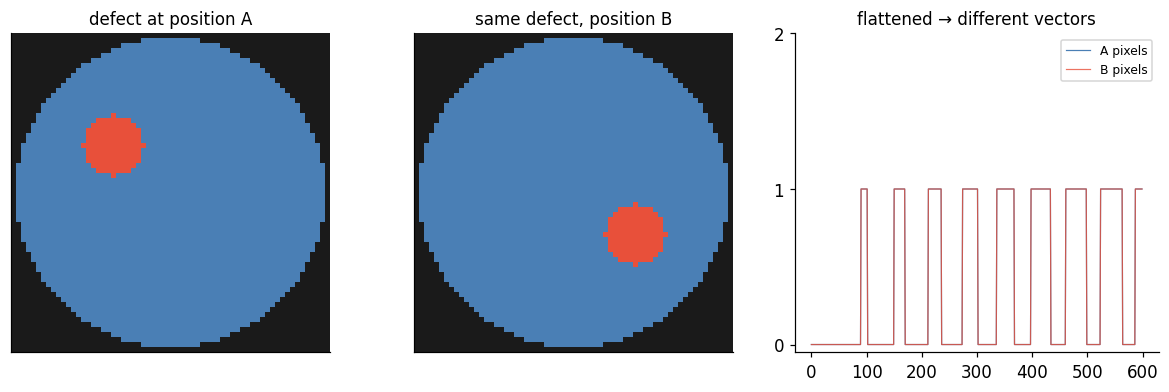

In [17]:
def blob_wafer(cx, cy, r=6):
    w = np.ones((64,64), dtype=int)                 # 1 = pass everywhere
    yy,xx = np.ogrid[:64,:64]
    mask_out = (xx-31.5)**2 + (yy-31.5)**2 > 31**2
    w[mask_out] = 0                                 # outside wafer
    w[(xx-cx)**2 + (yy-cy)**2 <= r**2] = 2          # a failing blob
    return w
a, b = blob_wafer(20,22), blob_wafer(44,40)
fig, axes = plt.subplots(1,3, figsize=(11,3.7))
show_wafer(axes[0], a, "defect at position A"); show_wafer(axes[1], b, "same defect, position B")
axes[2].plot(a.ravel()[:600], color=PASS, lw=0.8, label="A pixels")
axes[2].plot(b.ravel()[:600], color=FAIL, lw=0.8, alpha=0.8, label="B pixels")
axes[2].set_title("flattened → different vectors", fontsize=11); axes[2].legend(fontsize=8); axes[2].set_yticks([0,1,2])
show()

## 4 · Deep neural networks  (Part 1 · Section 4)

A deep network is logistic regression stacked: hidden layers of neurons, each a weighted
sum followed by a **ReLU**, between input and output. We first build intuition on a 2-D
"ring inside a ring" problem, then run a real deep net on the wafers.

In [18]:
from sklearn.datasets import make_circles
from sklearn.neural_network import MLPClassifier

Xc, yc = make_circles(n_samples=320, noise=0.07, factor=0.42, random_state=0)
xmin,xmax = Xc[:,0].min()-.3, Xc[:,0].max()+.3
ymin,ymax = Xc[:,1].min()-.3, Xc[:,1].max()+.3
gx,gyy = np.meshgrid(np.linspace(xmin,xmax,300), np.linspace(ymin,ymax,300))
grid = np.c_[gx.ravel(), gyy.ravel()]

def plot_boundary(ax, clf, title="", tcol=NAVY):
    Z = clf.predict(grid).reshape(gx.shape)
    ax.contourf(gx,gyy,Z, levels=[-.5,.5,1.5], colors=["#EAF1F8","#FBEDEB"])
    ax.contour(gx,gyy,Z, levels=[.5], colors=[NAVY], linewidths=1.7)
    ax.scatter(*Xc[yc==0].T, s=10, c=PASS, marker="o")
    ax.scatter(*Xc[yc==1].T, s=12, c=FAIL, marker="^")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, color=tcol, fontweight="bold", fontsize=11)

def fit_mlp(hidden, iters=400, lr=0.002, solver="adam"):
    return MLPClassifier(hidden, activation="relu", solver=solver, alpha=1e-4,
                         learning_rate_init=lr, max_iter=iters, random_state=0,
                         tol=0.0, n_iter_no_change=100000, early_stopping=False).fit(Xc, yc)

### Figure — a straight line cannot separate a ring; depth can
*Slide "A deep network bends the boundary."* Logistic regression scores ~0.49 (a coin
flip); a network with two hidden layers wraps the inner ring — accuracy 1.00.

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


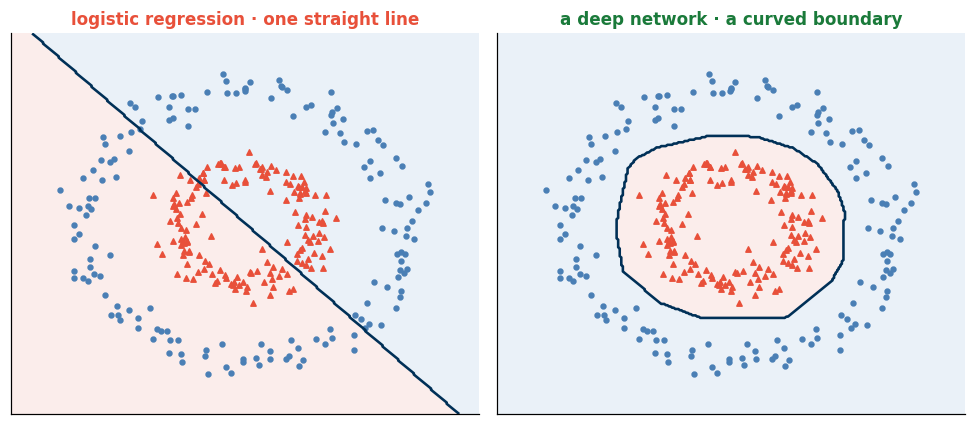

In [19]:
fig, ax = plt.subplots(1,2, figsize=(9,4))
plot_boundary(ax[0], LogisticRegression().fit(Xc,yc), "logistic regression · one straight line", FAIL)
plot_boundary(ax[1], fit_mlp((16,16)), "a deep network · a curved boundary", GOOD)
show()

### Figure — the boundary bends as it trains
*Slide "The boundary bends as it trains" (1/5).* Same run, four moments: the curve grows
outward to wrap the ring as the loss falls.

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (12) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


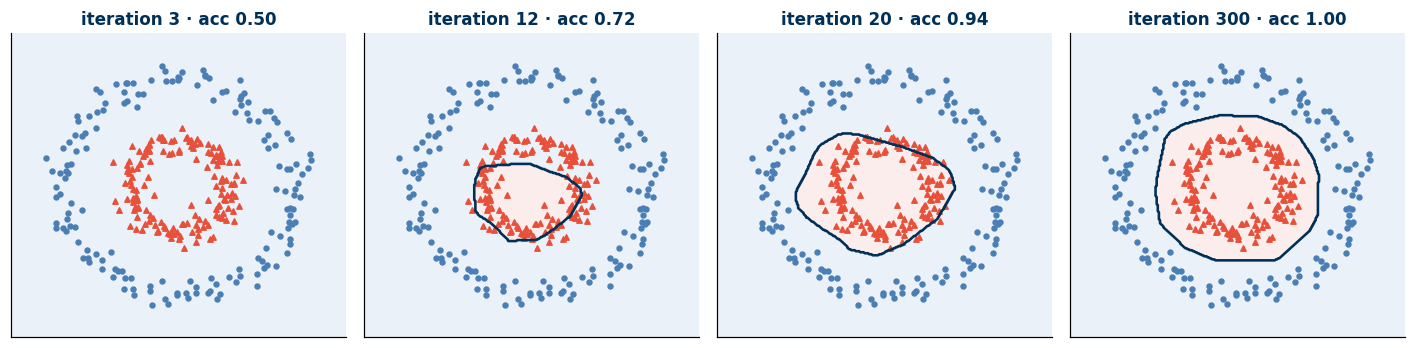

In [20]:
fig, ax = plt.subplots(1,4, figsize=(13,3.3))
for a,t in zip(ax,[3,12,20,300]):
    m = fit_mlp((16,16), iters=t)
    plot_boundary(a, m, f"iteration {t} · acc {m.score(Xc,yc):.2f}")
show()

### Figure — one ReLU is one straight "fold"
*Slide "Where the bending comes from: one ReLU, one fold" (2/5).* The kink in the ReLU
becomes a straight fold across the input plane: off (zero) on one side, ramping up on the other.

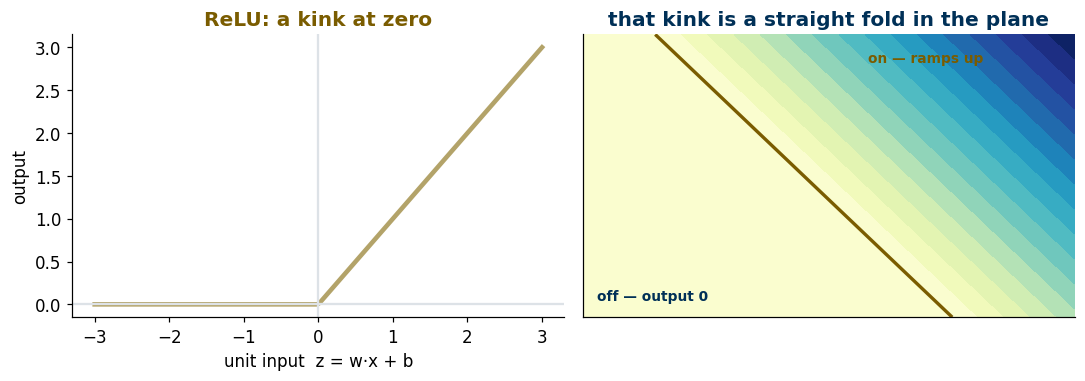

In [21]:
fig, (a1,a2) = plt.subplots(1,2, figsize=(10,3.6))
zz = np.linspace(-3,3,200)
a1.plot(zz, np.maximum(0,zz), color=GOLD, lw=3); a1.set_title("ReLU: a kink at zero", color="#7A5C00", fontweight="bold")
a1.set_xlabel("unit input  z = w·x + b"); a1.set_ylabel("output"); a1.axhline(0,color=GRID); a1.axvline(0,color=GRID)
w=np.array([1.3,0.8]); bb=0.2
val=np.maximum(0, gx*w[0]+gyy*w[1]+bb)
a2.contourf(gx,gyy,val, levels=20, cmap="YlGnBu")
a2.contour(gx,gyy, gx*w[0]+gyy*w[1]+bb, levels=[0], colors=["#7A5C00"], linewidths=2.2)
a2.set_title("that kink is a straight fold in the plane", color=NAVY, fontweight="bold")
a2.text(0.03,0.06,"off — output 0", transform=a2.transAxes, color=NAVY, fontweight="bold", fontsize=9)
a2.text(0.58,0.9,"on — ramps up", transform=a2.transAxes, color="#7A5C00", fontweight="bold", fontsize=9)
a2.set_xticks([]); a2.set_yticks([]); show()

### Figure — what a hidden unit is: four networks
*Slide "What a hidden unit is — four networks" (3/5).* The same two inputs and one output,
with 2, 4, 8, and 32 units in the single hidden layer. A hidden unit is one middle circle.

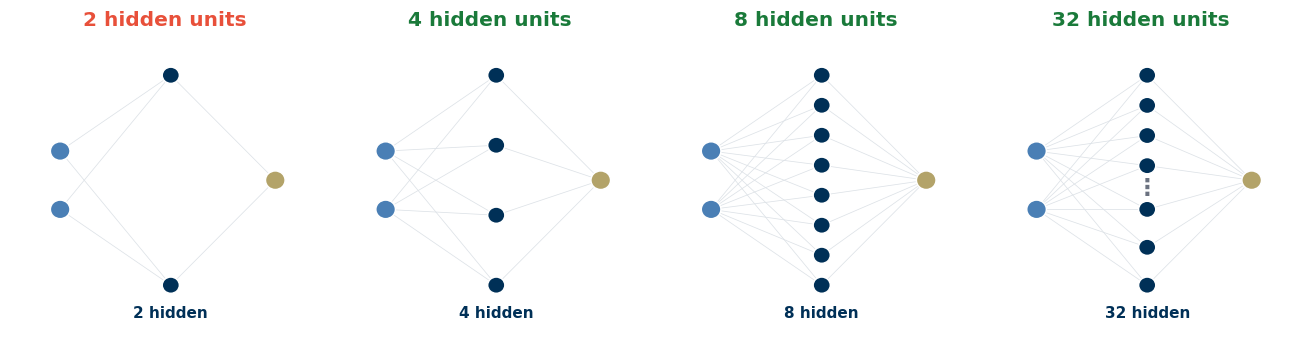

In [22]:
def draw_mlp(ax, H, title, tcol):
    xin,xhid,xout = 0.16,0.52,0.86
    inp=[(xin,0.6),(xin,0.4)]
    if H<=8: hid=[(xhid,v) for v in np.linspace(0.86,0.14,H)]; ell=False
    else:    hid=[(xhid,v) for v in np.r_[np.linspace(0.86,0.55,4),np.linspace(0.4,0.14,3)]]; ell=True
    for p in inp:
        for q in hid: ax.plot([p[0],q[0]],[p[1],q[1]],color=GRID,lw=0.5)
    for q in hid: ax.plot([q[0],xout],[q[1],0.5],color=GRID,lw=0.5)
    for p in inp: ax.add_patch(Circle(p,0.032,facecolor=PASS,ec="white",zorder=3))
    for q in hid: ax.add_patch(Circle(q,0.028,facecolor=NAVY,ec="white",zorder=3))
    ax.add_patch(Circle((xout,0.5),0.032,facecolor=GOLD,ec="white",zorder=3))
    if ell: ax.text(xhid,0.475,"⋮",ha="center",va="center",fontsize=15,color=MUT,fontweight="bold")
    ax.text(xhid,0.03,f"{H} hidden",ha="center",color=NAVY,fontweight="bold",fontsize=10)
    ax.set_title(title,color=tcol,fontweight="bold"); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off")
fig,ax=plt.subplots(1,4,figsize=(12,3.2))
for a,(H,c) in zip(ax,[(2,FAIL),(4,GOOD),(8,GOOD),(32,GOOD)]): draw_mlp(a,H,f"{H} hidden units",c)
show()

### Figure — more hidden units, more folds, a rounder boundary
*Slide "More hidden units, more folds, a rounder boundary" (4/5).* 2 units → a line; 4 →
a box that finally encloses the ring; 8 → an octagon; 32 → a smooth circle.

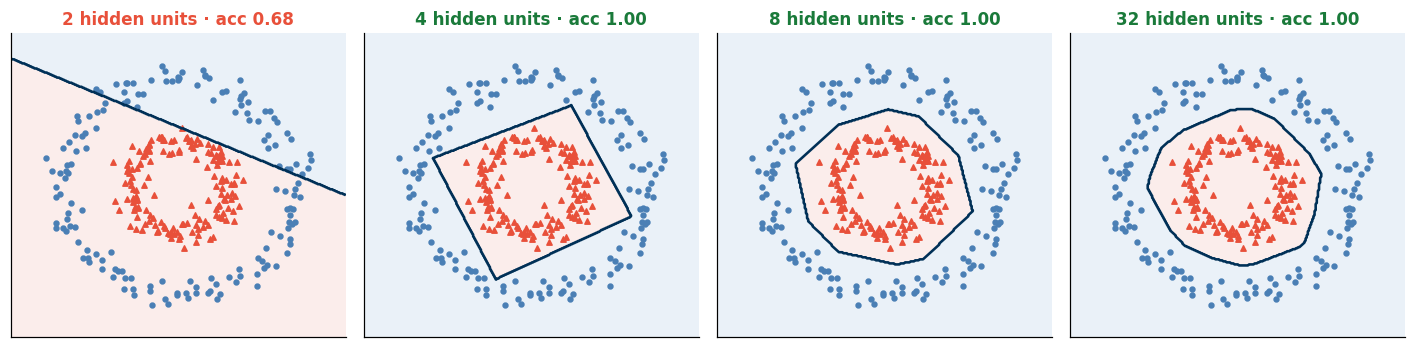

In [23]:
fig,ax=plt.subplots(1,4,figsize=(13,3.3))
for a,H in zip(ax,[2,4,8,32]):
    m=fit_mlp((H,), iters=2000, solver="lbfgs")
    plot_boundary(a,m,f"{H} hidden units · acc {m.score(Xc,yc):.2f}", GOOD if m.score(Xc,yc)>.95 else FAIL)
show()

### Figure — many folds make the curve
*Slide "Many folds make the curve" (5/5).* The eight fold-lines of an 8-unit network (left)
combine into one closed boundary (right).

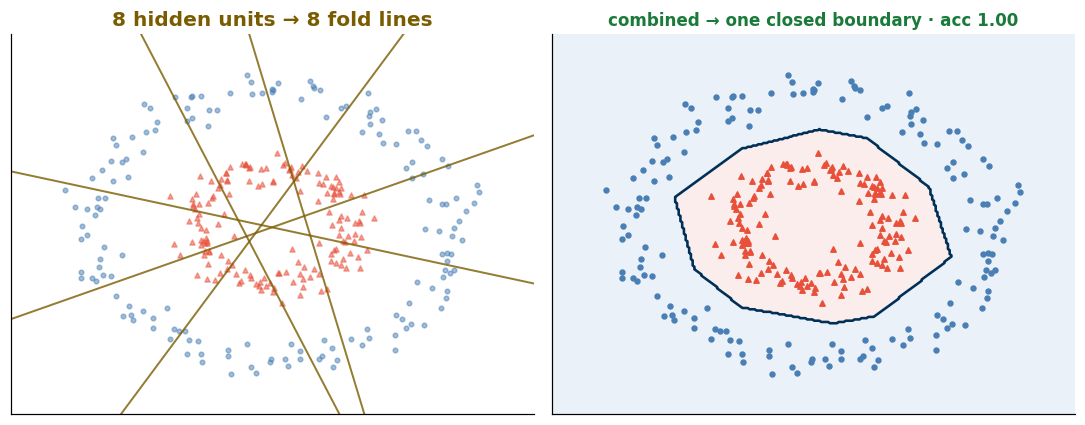

In [24]:
m8 = fit_mlp((8,), iters=3000, solver="lbfgs")
Wf, bf = m8.coefs_[0], m8.intercepts_[0]
fig,(b1,b2)=plt.subplots(1,2,figsize=(10,4))
b1.scatter(*Xc[yc==0].T,s=9,c=PASS,alpha=.5); b1.scatter(*Xc[yc==1].T,s=11,c=FAIL,marker="^",alpha=.5)
xs=np.array([xmin,xmax])
for j in range(8):
    wj,bj=Wf[:,j],bf[j]
    if abs(wj[1])>1e-6: b1.plot(xs,-(wj[0]*xs+bj)/wj[1],color="#7A5C00",lw=1.3,alpha=.8)
b1.set_xlim(xmin,xmax); b1.set_ylim(ymin,ymax); b1.set_xticks([]); b1.set_yticks([])
b1.set_title("8 hidden units → 8 fold lines", color="#7A5C00", fontweight="bold")
plot_boundary(b2,m8,f"combined → one closed boundary · acc {m8.score(Xc,yc):.2f}", GOOD)
show()

### Figure — ReLU vs the sigmoid, and the softmax output
*Slides "The activation: ReLU vs the sigmoid" and "The output head: softmax over nine
classes."* ReLU keeps gradients alive through depth; softmax turns nine raw scores into
probabilities that sum to one.

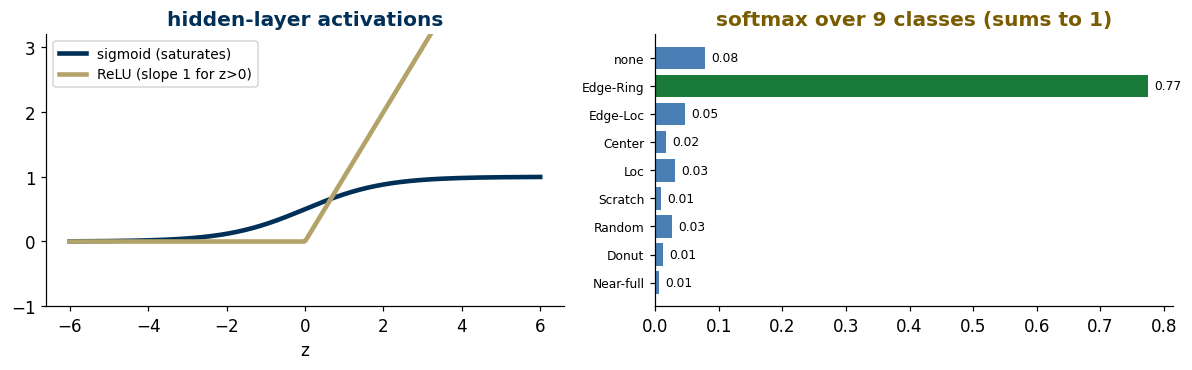

In [25]:
fig, ax = plt.subplots(1,2, figsize=(11,3.5))
zz=np.linspace(-6,6,300)
ax[0].plot(zz, sigmoid(zz), color=NAVY, lw=3, label="sigmoid (saturates)")
ax[0].plot(zz, np.maximum(0,zz), color=GOLD, lw=3, label="ReLU (slope 1 for z>0)")
ax[0].set_ylim(-1,3.2); ax[0].legend(fontsize=9); ax[0].set_xlabel("z")
ax[0].set_title("hidden-layer activations", color=NAVY, fontweight="bold")
logits=np.array([1.1,3.4,0.6,-0.4,0.2,-1.1,0.0,-0.8,-1.6]); probs=np.exp(logits)/np.exp(logits).sum()
yy=np.arange(9)[::-1]
ax[1].barh(yy, probs, color=[GOOD if p==probs.max() else PASS for p in probs])
ax[1].set_yticks(yy); ax[1].set_yticklabels(CLASSES, fontsize=8)
for i,p in zip(yy,probs): ax[1].text(p+0.01,i,f"{p:.2f}",va="center",fontsize=8)
ax[1].set_title("softmax over 9 classes (sums to 1)", color="#7A5C00", fontweight="bold")
show()

### Figure — backpropagation, schematically
*Slides "How a deep network learns: backpropagation" and "Backpropagation, step by step."*
Forward pass produces the loss; the backward pass sends the error back through the layers
(chain rule) to give every weight its gradient. For softmax+cross-entropy the output error
is simply $(\text{prediction}-\text{truth})$.

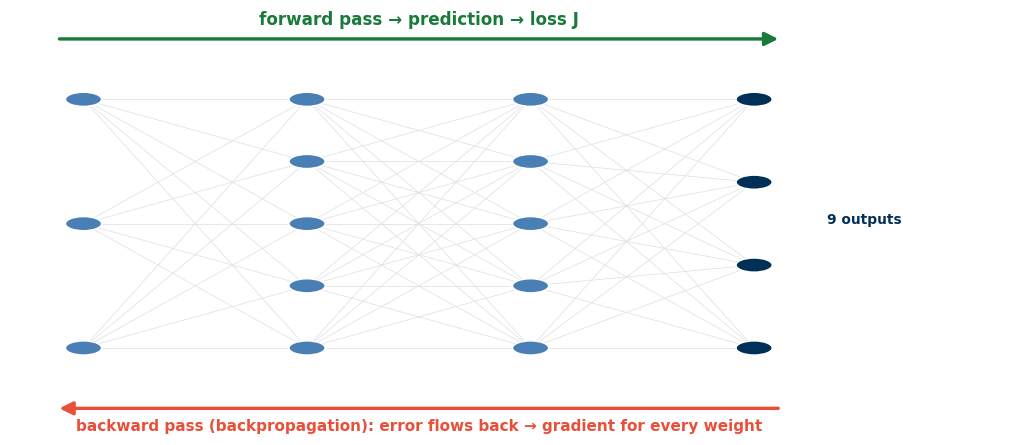

In [26]:
fig, ax = plt.subplots(figsize=(9.5,4.2)); ax.axis("off"); ax.set_xlim(0,1.1); ax.set_ylim(-.06,1.1)
sizes=[3,5,5,4]; xs=np.linspace(0.08,0.82,4); cols=[]
for li,nn in enumerate(sizes):
    ys=np.linspace(0.15,0.85,nn); cols.append([(xs[li],v) for v in ys])
for li in range(3):
    for p in cols[li]:
        for q in cols[li+1]: ax.plot([p[0],q[0]],[p[1],q[1]],color=GRID,lw=0.5)
for li,layer in enumerate(cols):
    for p in layer: ax.add_patch(Circle(p,0.02,facecolor=(NAVY if li==3 else PASS),ec="white",zorder=3))
ax.add_patch(FancyArrowPatch((0.05,1.02),(0.85,1.02),arrowstyle="-|>",mutation_scale=18,color=GOOD,lw=2.2))
ax.text(0.45,1.06,"forward pass → prediction → loss J", ha="center", color=GOOD, fontweight="bold")
ax.add_patch(FancyArrowPatch((0.85,-0.02),(0.05,-0.02),arrowstyle="-|>",mutation_scale=18,color=FAIL,lw=2.2))
ax.text(0.45,-0.05,"backward pass (backpropagation): error flows back → gradient for every weight",
        ha="center", va="top", color=FAIL, fontweight="bold", fontsize=10)
ax.text(0.9,0.5,"9 outputs",color=NAVY,fontsize=9,fontweight="bold"); show()

### The deep network on the wafers
*Slides "The network we actually trained," "How training converged," "So how does a DNN do
on the wafers?"* Two hidden layers (256, 128), ~1.08M weights, trained on the same
lot-grouped split with the classes balanced. It is **trainable but not better than logistic
regression** — depth was not the missing piece.

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder().fit(CLASSES)

def balanced_train_idx(target=2500, seed=0):
    r = np.random.default_rng(seed); idx=[]
    for c in CLASSES:
        ci = np.where(y[tr]==c)[0]
        idx.append(r.choice(ci, target, replace=len(ci)<target))
    idx = np.concatenate(idx); r.shuffle(idx); return idx

bidx = balanced_train_idx()
Xb, yb = Xf[tr][bidx], le.transform(y[tr][bidx])

def train_wafer_mlp(hidden):
    m = MLPClassifier(hidden, activation="relu", solver="adam", alpha=1e-4, batch_size=256,
                      learning_rate_init=1e-3, max_iter=60, early_stopping=True,
                      n_iter_no_change=6, validation_fraction=0.1, random_state=0)
    m.fit(Xb, yb); return m

mlp2 = train_wafer_mlp((256,128))
p_dnn = le.inverse_transform(mlp2.predict(Xf[te]))
nparam = sum(c.size for c in mlp2.coefs_) + sum(b.size for b in mlp2.intercepts_)
print(f"DNN (256,128) · {nparam:,} weights · {mlp2.n_iter_} epochs")
print(f"accuracy {accuracy_score(y[te],p_dnn):.3f} · macro-F1 {f1_score(y[te],p_dnn,average='macro'):.3f}")

DNN (256,128) · 1,082,889 weights · 34 epochs
accuracy 0.803 · macro-F1 0.450


### Figure — where the DNN's weights live, and how training converged
*Slides "The network we actually trained" and "How training converged."* ~97% of the
weights sit in the first pixel-facing layer; the loss converges cleanly.

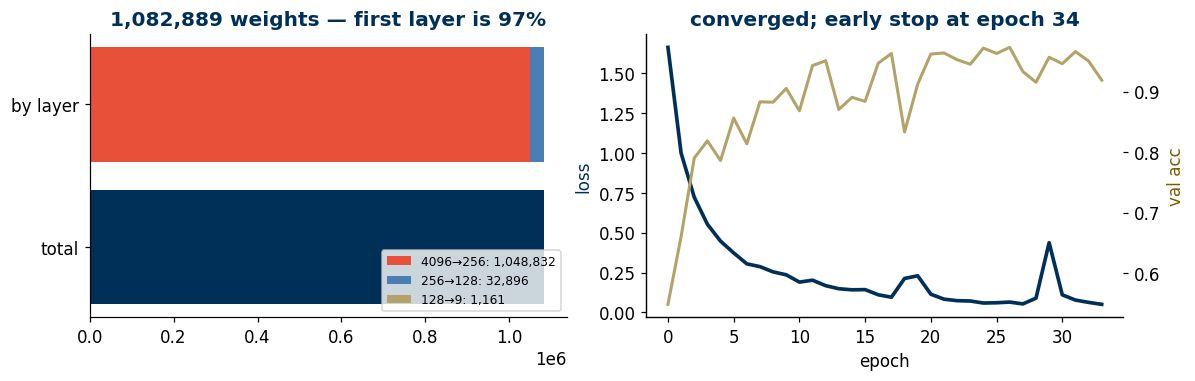

In [28]:
arch=[4096,256,128,9]; per=[arch[k]*arch[k+1]+arch[k+1] for k in range(3)]
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,3.6))
a1.barh([0],[sum(per)],color=NAVY); left=0
for v,c,lab in zip(per,[FAIL,PASS,GOLD],["4096→256","256→128","128→9"]):
    a1.barh([1],[v],left=left,color=c,label=f"{lab}: {v:,}"); left+=v
a1.set_yticks([0,1]); a1.set_yticklabels(["total","by layer"]); a1.legend(fontsize=8,loc="lower right")
a1.set_title(f"{sum(per):,} weights — first layer is {per[0]/sum(per)*100:.0f}%", color=NAVY, fontweight="bold")
a2.plot(mlp2.loss_curve_, color=NAVY, lw=2.4, label="training loss")
a2b=a2.twinx(); a2b.plot(mlp2.validation_scores_, color=GOLD, lw=2, label="val accuracy")
a2.set_xlabel("epoch"); a2.set_ylabel("loss", color=NAVY); a2b.set_ylabel("val acc", color="#7A5C00")
a2.set_title(f"converged; early stop at epoch {mlp2.n_iter_}", color=NAVY, fontweight="bold")
show()

### Figure — a DNN does no better than logistic regression
*Slide "So how does a DNN do on the wafers?"* Same split, same flattened pixels. The
million-parameter network lands right where logistic regression did, and fails on exactly
the same position-varying classes (Loc, Scratch).

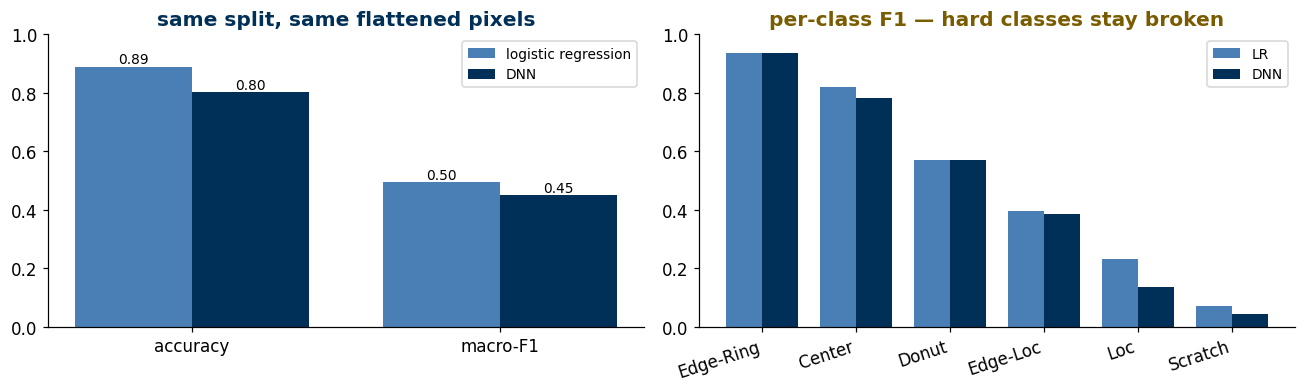

In [29]:
lr_pc = precision_recall_fscore_support(y[te], p_lr, labels=CLASSES, zero_division=0)[2]
dn_pc = precision_recall_fscore_support(y[te], p_dnn, labels=CLASSES, zero_division=0)[2]
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,3.7))
mA=[accuracy_score(y[te],p_lr), f1_score(y[te],p_lr,average='macro')]
mB=[accuracy_score(y[te],p_dnn), f1_score(y[te],p_dnn,average='macro')]
xx=np.arange(2); w=.38
a1.bar(xx-w/2,mA,w,label="logistic regression",color=PASS); a1.bar(xx+w/2,mB,w,label="DNN",color=NAVY)
for i,(u,v) in enumerate(zip(mA,mB)):
    a1.text(i-w/2,u+.01,f"{u:.2f}",ha="center",fontsize=9); a1.text(i+w/2,v+.01,f"{v:.2f}",ha="center",fontsize=9)
a1.set_xticks(xx); a1.set_xticklabels(["accuracy","macro-F1"]); a1.set_ylim(0,1); a1.legend(fontsize=9)
a1.set_title("same split, same flattened pixels", color=NAVY, fontweight="bold")
cls=["Edge-Ring","Center","Donut","Edge-Loc","Loc","Scratch"]; ii=[CLASSES.index(c) for c in cls]
a2.bar(np.arange(6)-w/2,[lr_pc[k] for k in ii],w,label="LR",color=PASS)
a2.bar(np.arange(6)+w/2,[dn_pc[k] for k in ii],w,label="DNN",color=NAVY)
a2.set_xticks(range(6)); a2.set_xticklabels(cls,rotation=18,ha="right"); a2.set_ylim(0,1); a2.legend(fontsize=9)
a2.set_title("per-class F1 — hard classes stay broken", color="#7A5C00", fontweight="bold")
show()

### Does more depth help? A 4-hidden-layer network
*Slides "Would more depth help?" through "Why depth didn't move the needle."* Add two more
layers (64, 32). Parameters barely grow (~1% — the first layer already holds ~96%), and
accuracy/macro-F1 do not improve.

2 hidden: 1,082,889 weights · acc 0.803 · macro-F1 0.450
4 hidden: 1,092,361 weights · acc 0.671 · macro-F1 0.413


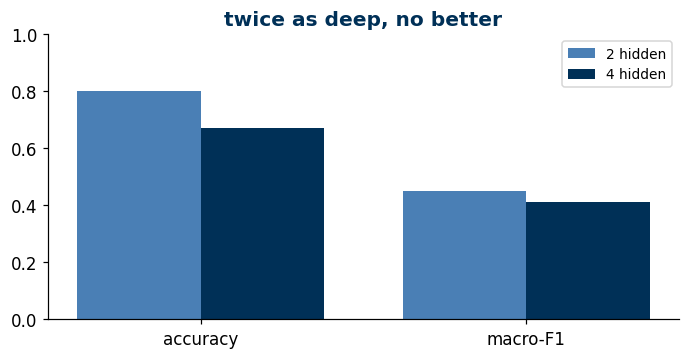

In [30]:
mlp4 = train_wafer_mlp((256,128,64,32))
p_dnn4 = le.inverse_transform(mlp4.predict(Xf[te]))
np4 = sum(c.size for c in mlp4.coefs_)+sum(b.size for b in mlp4.intercepts_)
print(f"2 hidden: {nparam:,} weights · acc {accuracy_score(y[te],p_dnn):.3f} · macro-F1 {f1_score(y[te],p_dnn,average='macro'):.3f}")
print(f"4 hidden: {np4:,} weights · acc {accuracy_score(y[te],p_dnn4):.3f} · macro-F1 {f1_score(y[te],p_dnn4,average='macro'):.3f}")
fig,ax=plt.subplots(figsize=(6.4,3.4))
mB=[accuracy_score(y[te],p_dnn), f1_score(y[te],p_dnn,average='macro')]
mC=[accuracy_score(y[te],p_dnn4), f1_score(y[te],p_dnn4,average='macro')]
xx=np.arange(2); w=.38
ax.bar(xx-w/2,mB,w,label="2 hidden",color=PASS); ax.bar(xx+w/2,mC,w,label="4 hidden",color=NAVY)
ax.set_xticks(xx); ax.set_xticklabels(["accuracy","macro-F1"]); ax.set_ylim(0,1); ax.legend(fontsize=9)
ax.set_title("twice as deep, no better", color=NAVY, fontweight="bold"); show()

## 5 · Convolutional networks  (Part 1 · Section 5)

The fix for the blind spot is a layer built for space. A **filter** is a small grid slid
across the image; because the same filter is reused everywhere, it detects a pattern
wherever it appears (translation invariance) with very few weights.

### Figure — why a wafer map has three channels
*Slide "Why the wafer map has three channels."* Each pixel is one of three categories
(outside / pass / fail), so we one-hot it into three binary planes rather than feeding a
single 0/1/2 number.

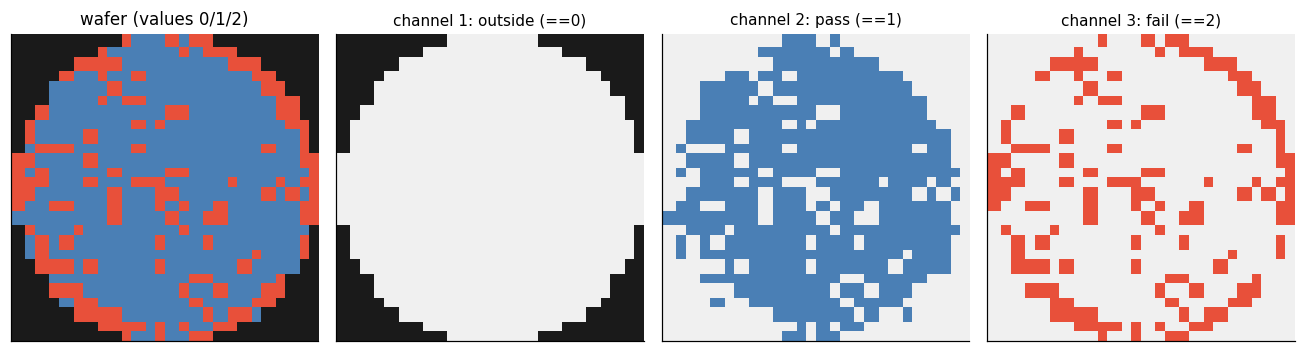

In [31]:
w = X[np.where(y=="Edge-Ring")[0][0]]
fig, ax = plt.subplots(1,4, figsize=(12,3.4))
show_wafer(ax[0], w, "wafer (values 0/1/2)")
for k,(name,col) in enumerate([("outside (==0)","#1a1a1a"),("pass (==1)",PASS),("fail (==2)",FAIL)]):
    ax[k+1].imshow((w==k).astype(int), cmap=ListedColormap(["#F0F0F0", col]), interpolation="nearest")
    ax[k+1].set_title(f"channel {k+1}: {name}", fontsize=10); ax[k+1].set_xticks([]); ax[k+1].set_yticks([])
show()

### Figure — a filter is a pattern detector
*Slides "A filter is a pattern detector" and "The convolution operation, step by step."*
A 3×3 vertical-edge filter slid over the fail-channel lights up exactly where the pattern
changes. Convolution is just multiply-and-add on each patch.

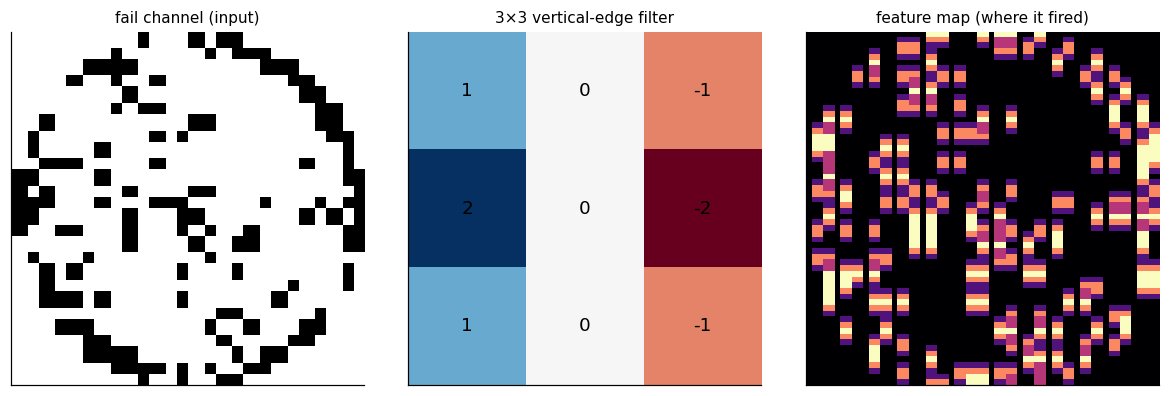

In [32]:
def conv2d(img, k):
    kh,kw = k.shape; H,W = img.shape
    out = np.zeros((H-kh+1, W-kw+1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i,j] = np.sum(img[i:i+kh, j:j+kw]*k)
    return out
fail = (w==2).astype(float)
vedge = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])   # vertical-edge (Sobel) filter
fmap = conv2d(fail, vedge)
fig, ax = plt.subplots(1,3, figsize=(11,3.6))
ax[0].imshow(fail, cmap="gray_r"); ax[0].set_title("fail channel (input)", fontsize=10)
ax[1].imshow(vedge, cmap="RdBu", vmin=-2, vmax=2)
for i in range(3):
    for j in range(3): ax[1].text(j,i,vedge[i,j],ha="center",va="center",fontsize=12)
ax[1].set_title("3×3 vertical-edge filter", fontsize=10)
ax[2].imshow(np.abs(fmap), cmap="magma"); ax[2].set_title("feature map (where it fired)", fontsize=10)
for a in ax: a.set_xticks([]); a.set_yticks([])
show()

### Figure — padding, stride, and max-pooling
*Slides "Padding," "Stride," and "Pooling layers."* Padding keeps the output size; stride
downsamples by stepping the filter; max-pooling summarises each 2×2 block by its strongest
response (and adds a little tolerance to small shifts).

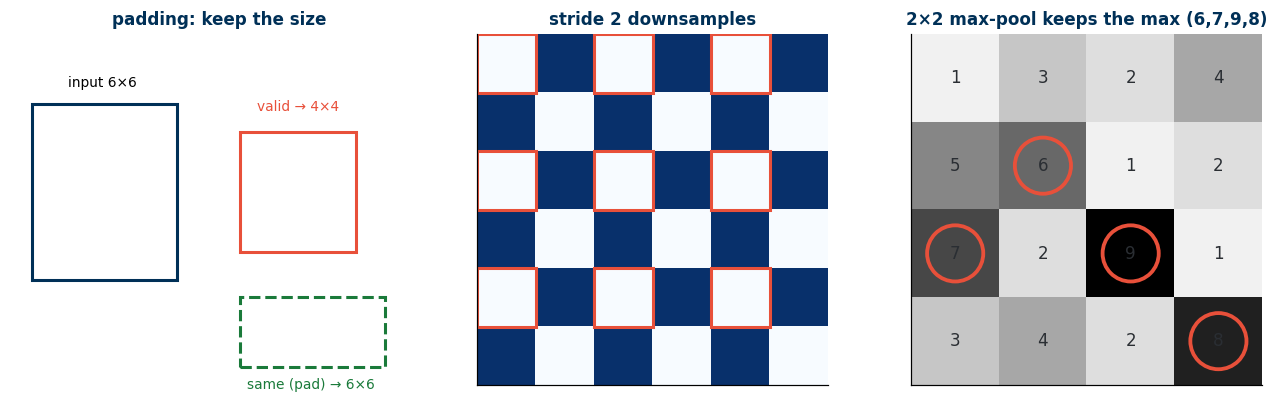

In [33]:
fig, ax = plt.subplots(1,3, figsize=(12,3.8))
# padding: valid vs same output sizes for a 3x3 filter on 6x6
ax[0].axis("off"); ax[0].set_title("padding: keep the size", color=NAVY, fontweight="bold", fontsize=11)
ax[0].add_patch(plt.Rectangle((0.05,0.3),0.35,0.5, fill=False, ec=NAVY, lw=2))
ax[0].text(0.22,0.85,"input 6×6", ha="center", fontsize=9)
ax[0].add_patch(plt.Rectangle((0.55,0.38),0.28,0.34, fill=False, ec=FAIL, lw=2))
ax[0].text(0.69,0.78,"valid → 4×4", ha="center", fontsize=9, color=FAIL)
ax[0].add_patch(plt.Rectangle((0.55,0.05),0.35,0.20, fill=False, ec=GOOD, lw=2, ls="--"))
ax[0].text(0.72,0.02,"same (pad) → 6×6", ha="center", va="top", fontsize=9, color=GOOD)
# stride
gridimg = np.add.outer(np.arange(6), np.arange(6)) % 2
ax[1].imshow(gridimg, cmap="Blues"); ax[1].set_title("stride 2 downsamples", color=NAVY, fontweight="bold", fontsize=11)
for i in range(0,6,2):
    for j in range(0,6,2): ax[1].add_patch(plt.Rectangle((j-.5,i-.5),1,1, fill=False, ec=FAIL, lw=2))
ax[1].set_xticks([]); ax[1].set_yticks([])
# maxpool
pool_in = np.array([[1,3,2,4],[5,6,1,2],[7,2,9,1],[3,4,2,8]])
ax[2].imshow(pool_in, cmap="Greys", vmin=0, vmax=9)
for i in range(4):
    for j in range(4): ax[2].text(j,i,pool_in[i,j],ha="center",va="center",fontsize=11,color=BODY)
for (i,j) in [(1,1),(2,0),(2,2),(3,3)]: ax[2].add_patch(plt.Circle((j,i),0.32, color=FAIL, fill=False, lw=2.5))
ax[2].set_title("2×2 max-pool keeps the max (6,7,9,8)", color=NAVY, fontweight="bold", fontsize=11)
ax[2].set_xticks([]); ax[2].set_yticks([])
show()

### Figure — a complete ConvNet
*Slides "A complete ConvNet" and "The architecture, as a network."* Stack
`[conv → ReLU → pool]` blocks; spatial size shrinks while channel depth grows, then a
global-average-pool and a softmax over nine classes.

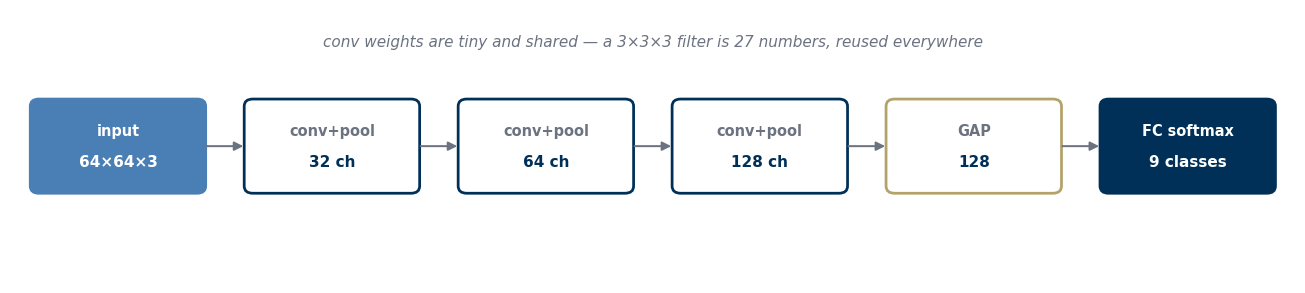

In [34]:
fig, ax = plt.subplots(figsize=(12,2.8)); ax.axis("off"); ax.set_xlim(0,12); ax.set_ylim(0,3)
stages=[("input","64×64×3",PASS),("conv+pool","32 ch",NAVY),("conv+pool","64 ch",NAVY),
        ("conv+pool","128 ch",NAVY),("GAP","128",GOLD),("FC softmax","9 classes",NAVY)]
bw=1.6; xs=np.linspace(0.2,12-bw-0.2,6)
for i,(nm,sub,col) in enumerate(stages):
    ax.add_patch(FancyBboxPatch((xs[i],1.0),bw,1.0,boxstyle="round,pad=0.02,rounding_size=0.08",
                 ec=col, fc=(col if i in(0,5) else "white"), lw=1.8))
    tc="white" if i in(0,5) else NAVY
    ax.text(xs[i]+bw/2,1.62,nm,ha="center",fontsize=9.5,fontweight="bold",color=(tc if i in(0,5) else MUT))
    ax.text(xs[i]+bw/2,1.28,sub,ha="center",fontsize=10,fontweight="bold",color=tc)
    if i<5: ax.add_patch(FancyArrowPatch((xs[i]+bw,1.5),(xs[i+1],1.5),arrowstyle="-|>",mutation_scale=12,color=MUT,lw=1.3))
ax.text(6,2.6,"conv weights are tiny and shared — a 3×3×3 filter is 27 numbers, reused everywhere",
        ha="center", fontsize=10, style="italic", color=MUT)
show()

### Training the CNN  (code + reported results)
*Slides "CNN results" and the scoreboard.* A convolutional net wants a GPU, so the training
cell below is complete and correct but **guarded by `RUN_CNN`** — flip it to `True` in an
environment with PyTorch to run it. The numbers the lecture reports (full test set) are
printed underneath.

In [35]:
RUN_CNN = False   # set True with PyTorch + a GPU to train the convolutional network

if RUN_CNN:
    import torch, torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    # one-hot the 3 categories into channels: (N,3,64,64)
    def to_chan(A): return np.stack([(A==0),(A==1),(A==2)],1).astype("float32")
    Xtr = torch.tensor(to_chan(X[tr])); ytr_t = torch.tensor(le.transform(y[tr]))
    Xte = torch.tensor(to_chan(X[te])); yte_t = torch.tensor(le.transform(y[te]))
    class CNN(nn.Module):
        def __init__(s):
            super().__init__()
            def blk(i,o): return nn.Sequential(nn.Conv2d(i,o,3,padding=1), nn.ReLU(), nn.MaxPool2d(2))
            s.f = nn.Sequential(blk(3,32), blk(32,64), blk(64,128), nn.AdaptiveAvgPool2d(1))
            s.head = nn.Linear(128,9)
        def forward(s,x): return s.head(s.f(x).flatten(1))
    net = CNN().to(dev)
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    # class-balanced loss
    counts = np.bincount(le.transform(y[tr]), minlength=9)
    wts = torch.tensor((counts.sum()/(9*counts)).astype("float32")).to(dev)
    lossf = nn.CrossEntropyLoss(weight=wts)
    dl = DataLoader(TensorDataset(Xtr,ytr_t), batch_size=128, shuffle=True)
    for epoch in range(15):
        net.train()
        for xb,yb_ in dl:
            opt.zero_grad(); loss=lossf(net(xb.to(dev)), yb_.to(dev)); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad():
        pred = le.inverse_transform(net(Xte.to(dev)).argmax(1).cpu().numpy())
    print("CNN  accuracy", round(accuracy_score(y[te],pred),3),
          " macro-F1", round(f1_score(y[te],pred,average='macro'),3))
else:
    print("CNN not run (RUN_CNN = False).")
    print("Reported in the lecture (full WM-811K test set):")
    print("  CNN  ·  ~94,400 weights  ·  accuracy 0.939  ·  macro-F1 0.777  ·  Scratch F1 0.557")

CNN not run (RUN_CNN = False).
Reported in the lecture (full WM-811K test set):
  CNN  ·  ~94,400 weights  ·  accuracy 0.939  ·  macro-F1 0.777  ·  Scratch F1 0.557


## 6 · The scoreboard  (Part 1 · closing)

*Slide "Scoreboard, end of Part 1."* The parameter column tells the story: the CNN reaches
the best macro-F1 with an order of magnitude **fewer** weights than the deep net — structure,
not raw capacity.

> The deep-net rows are measured here on the ~26K dev subset; logistic regression and the
> CNN rows are the lecture's full-test-set numbers, so their accuracies are not directly
> comparable across the line. The macro-F1 story — DNN ≈ LR ≪ CNN — holds either way.

In [36]:
import pandas as pd
board = pd.DataFrame([
    ["Majority baseline",            0,          0.854, 0.10,  0.000],
    ["Logistic regression",          36_873,     0.688, 0.473, 0.053],
    ["DNN — 2 layers (dev)",         nparam,     round(accuracy_score(y[te],p_dnn),3),  round(f1_score(y[te],p_dnn,average='macro'),3),  0.048],
    ["DNN — 4 layers (dev)",         np4,        round(accuracy_score(y[te],p_dnn4),3), round(f1_score(y[te],p_dnn4,average='macro'),3), 0.060],
    ["CNN (full test set)",          94_400,     0.939, 0.777, 0.557],
], columns=["Model","Parameters","Accuracy","Macro-F1","Scratch F1"])
board

,Model,Parameters,Accuracy,Macro-F1,Scratch F1
0,Majority baseline,0,0.854,0.100,0.000
1,Logistic regression,36873,0.688,0.473,0.053
2,DNN — 2 layers (dev),1082889,0.803,0.450,0.048
3,DNN — 4 layers (dev),1092361,0.671,0.413,0.060
4,CNN (full test set),94400,0.939,0.777,0.557


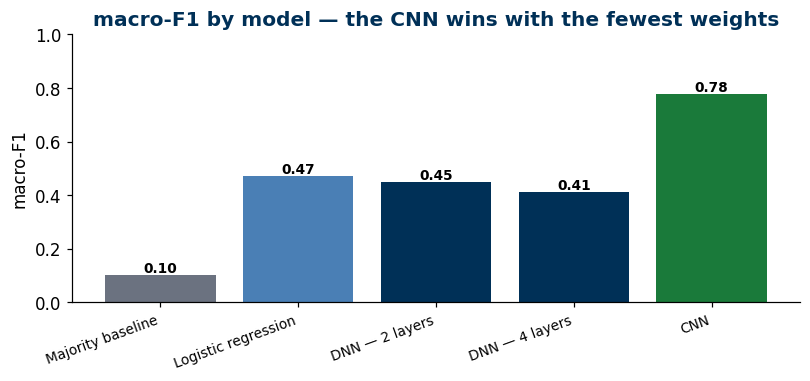

In [37]:
fig, ax = plt.subplots(figsize=(7.5,3.6))
names = board["Model"].str.replace(" (dev)","",regex=False).str.replace(" (full test set)","",regex=False)
cols = [MUT, PASS, NAVY, NAVY, GOOD]
ax.bar(range(5), board["Macro-F1"], color=cols)
for i,v in enumerate(board["Macro-F1"]): ax.text(i, v+0.01, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(range(5)); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("macro-F1"); ax.set_ylim(0,1)
ax.set_title("macro-F1 by model — the CNN wins with the fewest weights", color=NAVY, fontweight="bold")
show()

---
### Where this goes next

Logistic regression and the deep net both fail on the position-varying classes because a
flat pixel vector has no notion of space; the CNN's locality and weight sharing fix exactly
that. **Lecture 3** overturns even the CNN: 28 hand-built *physics* features plus a random
forest match its accuracy in seconds — and fail in the one place the physics doesn't hold.
That is the companion notebook `module 3 lecture 2.ipynb`.